# Exercise 4
## Your task:
Create a *Graph* where you perform two operations.

*Input:* `initial_state = AgentState(number1 = 10, number2 = 5, number3 = 7, number4 = 2, operation1 = "-", operation2 = "+", result1 = 0, result2 = 0)`
<br>
*Output:* `result1 == 5, result2 == 9`

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [4]:
# We now create an AgentState - shared data structure that keeps track of information as your application runs.

class AgentState(TypedDict):
    "Two numbers and an operation"
    number1: int
    number2: int
    number3: int
    number4: int
    operation1: str
    operation2: str
    result1: int
    result2: int

In [6]:
def adder1(state: AgentState) -> AgentState:
    """Node for first addition"""

    state['result1'] = state['number1'] + state['number2']

    return state

def subtractor1(state: AgentState) -> AgentState:
    """Node for first subtraction"""

    state['result1'] = state['number1'] - state['number2']

    return state

def adder2(state: AgentState) -> AgentState:
    """Node for second addition"""

    state['result2'] = state['number3'] + state['number4']

    return state

def subtractor2(state: AgentState) -> AgentState:
    """Node for second subtraction"""

    state['result2'] = state['number3'] - state['number4']

    return state

def decide_next_node_1(state: AgentState) -> AgentState:
    """Node determining the first operation and decides the next node"""

    if state['operation1'] == '+':
        return 'addition_operation'
    
    elif state['operation1'] == '-':
        return 'subtraction_operation'

def decide_next_node_2(state: AgentState) -> AgentState:
    """Node determining the second operation and decides the next node"""

    if state['operation2'] == '+':
        return 'addition_operation2'
    
    elif state['operation2'] == '-':
        return 'subtraction_operation2'

In [7]:
graph = StateGraph(AgentState)

graph.add_node('add_node', adder1)
graph.add_node('subtract_node', subtractor1)
graph.add_node('add_node2', adder2)
graph.add_node('subtract_node2', subtractor2)
graph.add_node('router', lambda state: state)  # passthrough function
graph.add_node('router2', lambda state: state)  # passthrough function

graph.add_edge(START, 'router')

graph.add_conditional_edges(
    'router',
    decide_next_node_1,
    {
        'addition_operation': 'add_node',
        'subtraction_operation': 'subtract_node',
    }
)

graph.add_edge('add_node', 'router2')
graph.add_edge('subtract_node', 'router2')

graph.add_conditional_edges(
    'router2',
    decide_next_node_2,
    {
        'addition_operation2': 'add_node2',
        'subtraction_operation2': 'subtract_node2',
    }
)

graph.add_edge('add_node2', END)
graph.add_edge('subtract_node2', END)

app = graph.compile()

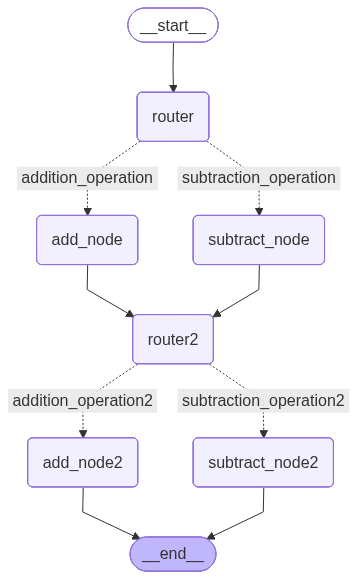

In [8]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
initial_state = AgentState(number1=15, number2=7, operation1='-', number3=21, number4=35, operation2='+')
answer = app.invoke(initial_state)
print(answer)
print(answer['result1'], answer['result2'])

{'number1': 15, 'number2': 7, 'number3': 21, 'number4': 35, 'operation1': '-', 'operation2': '+', 'result1': 8, 'result2': 56}
8 56


In [11]:
initial_state_2 = AgentState(number1=123, number2=456, operation1='+', number3=321, number4=27, operation2='-')
answer = app.invoke(initial_state_2)
print(answer)
print(answer['result1'], answer['result2'])

{'number1': 123, 'number2': 456, 'number3': 321, 'number4': 27, 'operation1': '+', 'operation2': '-', 'result1': 579, 'result2': 294}
579 294
